# Linking PG&E utility data with building polygons
This notebook will take Global Building Atlas polygons and link to the nearest PG&E feeder line.

In [ ]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import box
from shapely.geometry import MultiLineString
import matplotlib.pyplot as plt
import glob
import os
import folium

In [2]:
pd.set_option('display.max_columns', None)

In [ ]:
os.environ['PROJ_LIB'] = '/opt/anaconda3/share/proj'

### 1. Read in Data

**PGE line circuit**

In [3]:
pge_circuits = gpd.read_file("../../../../../capstone/electrigrid/data/utilities/pge_shapefiles/LineDetail.shp").to_crs("EPSG:4326")

ERROR 1: PROJ: proj_create_from_database: Open of /Users/sarak/.conda/envs/electrigrid-env/share/proj failed


In [ ]:
os.environ['PROJ_LIB'] = '/opt/anaconda3/share/proj'

In [5]:
pge_circuits.head(3)

,FeederId,FeederName,globalid,CSV_LineSe,LoadCapaci,voltage_kv,phase_cnt,limiting_m,limiting_c,ICA_Analys,lica_analy,Division,GenCapacit,GenericPVC,GenCapac_1,GenericCap,limiting_1,limiting_2,limiting_3,limiting_4,limiting_5,limiting_6,limiting_7,limiting_8,ScreenL,Publish,Last_Updat,SHAPE_Leng,geometry
0,062541102,MERIDIAN 1102,{3F991049-BA44-489F-A403-DA79E95B5F6A},3862041,0,12.0,3,None,None,May 2024,May 2024,Sacramento,0,0,0,0,None,None,None,None,None,None,None,None,Unlikely to pass,1,2025-06-02,145.642120,"LINESTRING (-121.95921 39.12370, -121.95951 39..."
1,043302102,MONROE 2102,{65E86C65-2474-4DE9-831A-73C5C6C88469},5458148,2380,21.0,3,None,None,Feb 2025,Feb 2025,Sonoma,60,70,2440,2440,None,None,None,None,None,None,None,None,Likely to pass,1,2025-06-02,9.102052,"LINESTRING (-122.73809 38.48070, -122.73809 38..."
2,063172101,MADISON 2101,{26A0B689-C08B-4AE6-AAC1-341797C5AC4E},3180180,0,21.0,3,None,None,Dec 2024,Dec 2024,Sacramento,0,0,0,0,None,None,None,None,None,None,None,None,Unlikely to pass,1,2025-06-02,4.571886,"LINESTRING (-122.01719 38.69234, -122.01714 38..."


Single family homes (Zillow point data) for Alameda county

In [6]:
alameda_buildings = gpd.read_file("../../../../../capstone/electrigrid/data/building_zillow_merges/alamedacounty_building_zillow_merge/non_multi_zillow_alameda.geojson")

In [7]:
alameda_buildings.head(3)

,type,year,room,heat,cool,own,unit,value,sqft_type,sqft,ID,GEOID,p_ID,area,code,index_right,source,id,height_m,var,region,bbox,area_m2,volume_m3,geometry
0,Multi,2000.0,1.0,None,None,None,40.0,499500.0,living,840.0,403,06001403302,468,PGE/SCE,RR106,2833938,osm,105058335,14.178774,11.995655,USA,"{'xmin': -122.27082929999999, 'ymin': 37.79499...",1424.845227,20202.558291,POINT (-122.27050 37.79521)
1,Multi,1976.0,2.0,None,None,O,53.0,1143597.0,living,1364.0,404,06001403302,468,PGE/SCE,RR106,2833928,osm,350754536,13.578455,5.557640,USA,"{'xmin': -122.2703524, 'ymin': 37.794816499999...",1351.261163,18348.038855,POINT (-122.26979 37.79507)
2,Multi,1976.0,2.0,None,None,O,53.0,831707.0,living,1202.0,405,06001403302,468,PGE/SCE,RR106,2833928,osm,350754536,13.578455,5.557640,USA,"{'xmin': -122.2703524, 'ymin': 37.794816499999...",1351.261163,18348.038855,POINT (-122.26979 37.79507)


In [8]:
#fig, ax = plt.subplots(figsize=(10, 9))
#pge_linedetail.plot(ax=ax)

Test bbox: -121.977774, 37.324955, -121.879069, 37.375036 (EPSG:4326)

In [9]:
#bbox = box(minx=-121.977774, miny=37.324955, maxx=-121.879069, maxy=37.375036 )
#bbox = gpd.GeoDataFrame(geometry=[bbox], crs=pge_linedetail.crs)

In [10]:
#bbox_circuits = gpd.clip(pge_linedetail, bbox)

In [11]:
#bbox_circuits.head()

In [12]:
#fig, axes = plt.subplots(1, 2, figsize=(15, 5))
#bbox_circuits.plot(ax=axes[0], column='FeederName')
#bbox_circuits.plot(ax=axes[1], column='LoadCapaci')

## Join buildings to circuits (single family homes)

<Axes: >

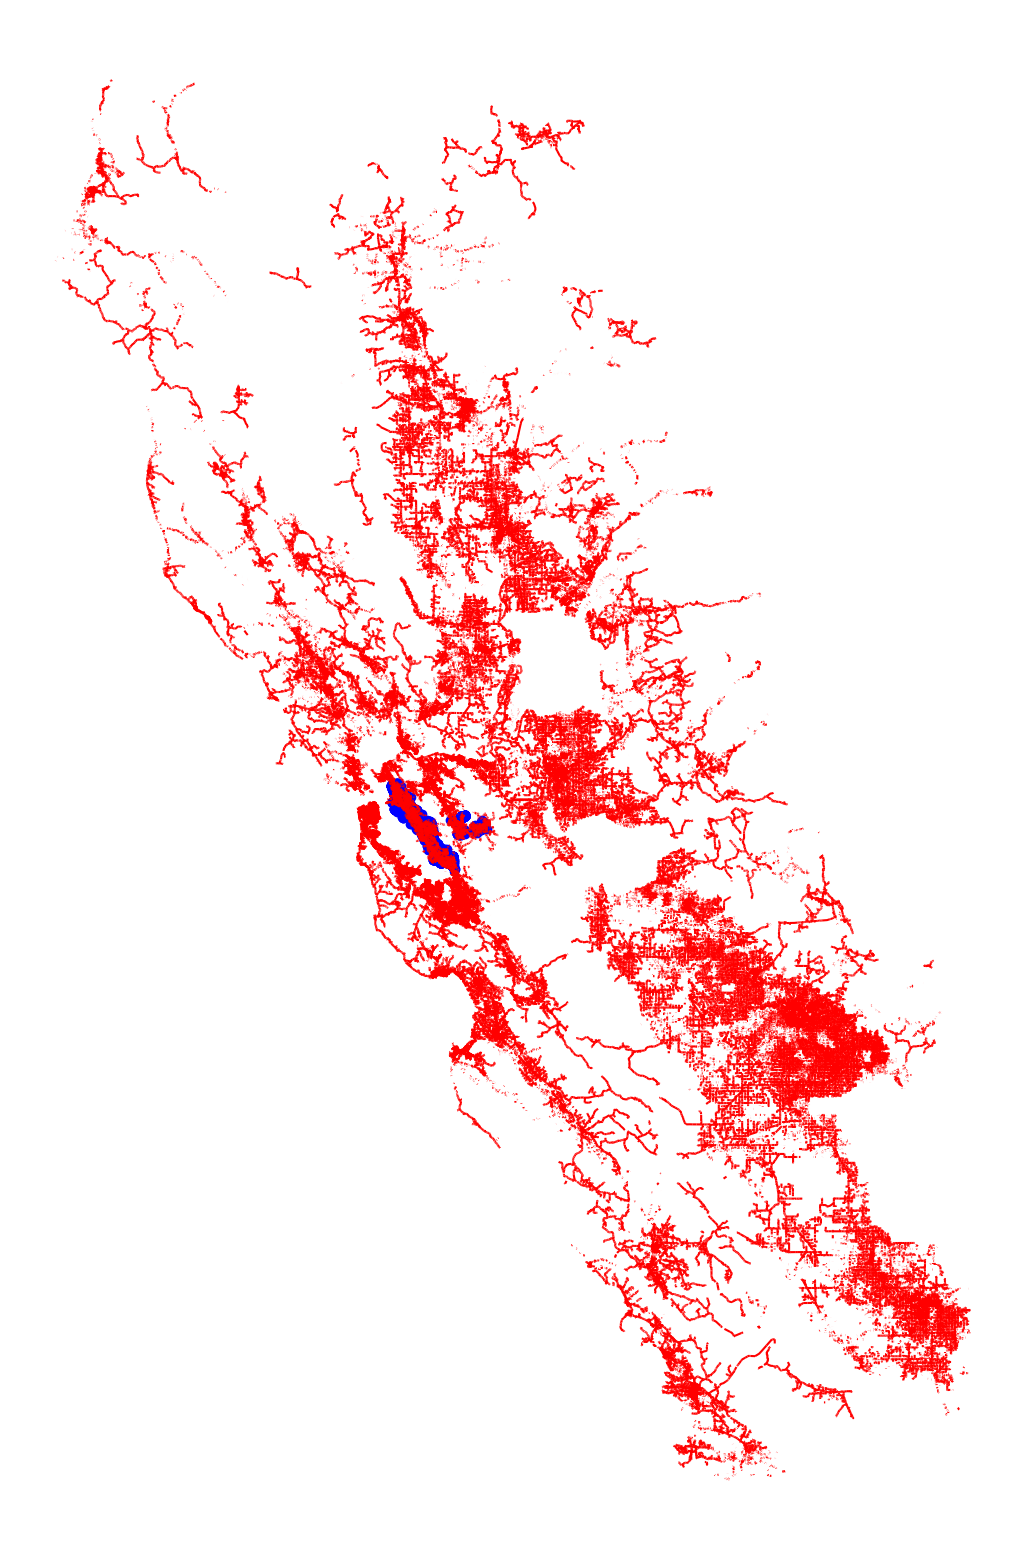

In [13]:
fig, ax = plt.subplots(figsize=(20, 20))

ax.axis('off')

alameda_buildings.plot(ax=ax, color='blue')

pge_circuits.plot(ax=ax, color='red')

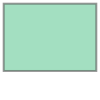

In [14]:
alameda_county_box = box(*alameda_buildings.total_bounds)

alameda_county_box

In [15]:
pge_clip = gpd.clip(pge_circuits, alameda_county_box)

In [16]:
pge_clip.columns

Index(['FeederId', 'FeederName', 'globalid', 'CSV_LineSe', 'LoadCapaci',
       'voltage_kv', 'phase_cnt', 'limiting_m', 'limiting_c', 'ICA_Analys',
       'lica_analy', 'Division', 'GenCapacit', 'GenericPVC', 'GenCapac_1',
       'GenericCap', 'limiting_1', 'limiting_2', 'limiting_3', 'limiting_4',
       'limiting_5', 'limiting_6', 'limiting_7', 'limiting_8', 'ScreenL',
       'Publish', 'Last_Updat', 'SHAPE_Leng', 'geometry'],
      dtype='object')

<Axes: >

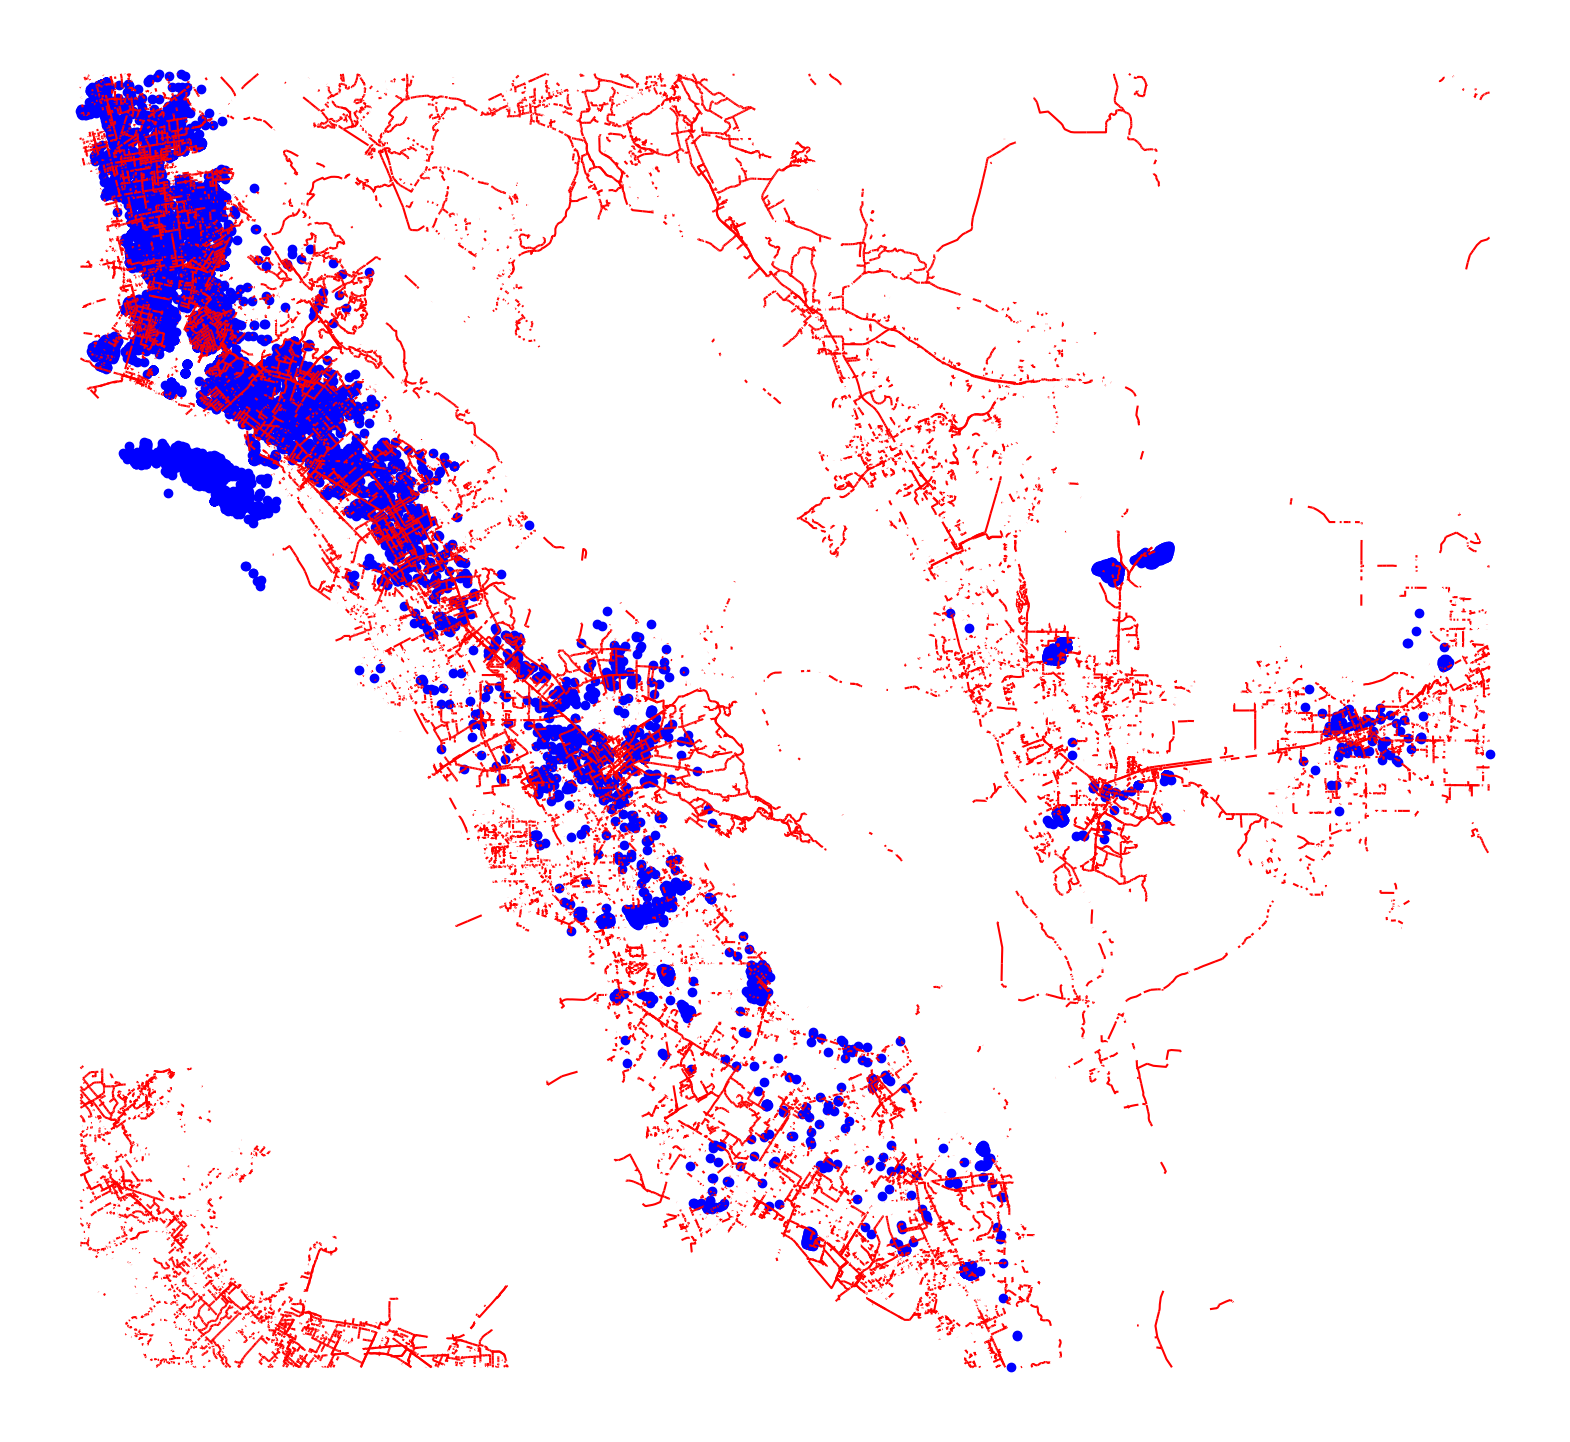

In [17]:
fig, ax = plt.subplots(figsize=(20, 20))

ax.axis('off')

alameda_buildings.plot(ax=ax, color='blue')

pge_clip.plot(ax=ax, color='red')

## Plot data interactively for ML labeling

In [ ]:
# Initilize folium map with specified center location
m = folium.Map(location=(37.6017, -121.7195), zoom_start=12)

circuit_popup = folium.GeoJsonPopup(fields=['CSV_LineSe', 'LoadCapaci'])

# Census layer
#folium.GeoJson(data=la_census,
               #style_function=lambda feature: {"fillColor":"gray", "color":"black"}).add_to(m)

# Buildings layer
folium.GeoJson(data=alameda_buildings,
               style_function=lambda feature: {"color":"red"}).add_to(m)

# Circuits layer
folium.GeoJson(data=pge_circuits, popup=circuit_popup, highlight_function=lambda feature: {"color":"orange"}).add_to(m)

display(m)

In [19]:
print(alameda_buildings.crs)
print(pge_circuits.crs)
print(alameda_buildings.total_bounds)

EPSG:4326
EPSG:4326
[-122.307132   37.471967 -121.716277   37.901203]


In [20]:
# Define conditions and choices
conditions = [
    pge_circuits['CSV_LineSe'].isin(['A', 'C']),
    pge_circuits['CSV_LineSe'].isin(['A', 'C'])
]
choices = ['feeder', 'trunk']

pge_circuits['segment_class'] = np.select(conditions, choices, default='other')